

---
# AirFly Insights Project

## Project Goal
The goal of this project is to analyze airline flight data to identify delay patterns, cancellation trends, airline performance, and airport congestion using data visualization techniques.

## KPIs
- Total number of flights
- Total delayed flights
- Average arrival delay
- Average departure delay
- Total cancellations
- Cancellation rate
- Airline with highest delay
- Airport with highest delay
- Most busy route
- Monthly delay trends

## Workflow
1. Load dataset
2. Explore data
3. Clean data
4. Feature engineering
5. Analysis
6. Visualization
7. Dashboard creation



In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("flights.csv")
df.head()

/tmp/ipykernel_698/4187578202.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape


(5051851, 31)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5051851 entries, 0 to 5051850
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    float64
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             float64
 24

In [ ]:
df.isnull().sum()


,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,13167
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [ ]:
memory = df.memory_usage(deep=True).sum() / (1024**3)
print("Memory usage in GB:", memory)


Memory usage in GB: 2.1046601496636868


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')


memory = df.memory_usage(deep=True).sum() / (1024**3)
print("Memory usage after optimization:", memory)


Memory usage after optimization: 1.0167750483378768


In [ ]:
df.to_csv("flights_optimized.csv", index=False)


In [ ]:
import pandas as pd
df = pd.read_csv("flights_optimized.csv")


/tmp/ipykernel_698/2032093078.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flights_optimized.csv")


In [ ]:
df = pd.read_csv("flights_optimized.csv", low_memory=False)


In [ ]:
#df['FLIGHT_DATE'] = pd.to_datetime(df['FLIGHT_DATE'])


In [ ]:
df['FLIGHT_DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])


In [ ]:
df[['YEAR', 'MONTH', 'DAY', 'FLIGHT_DATE']].head()


,YEAR,MONTH,DAY,FLIGHT_DATE
0,2015,1,1,2015-01-01
1,2015,1,1,2015-01-01
2,2015,1,1,2015-01-01
3,2015,1,1,2015-01-01
4,2015,1,1,2015-01-01


In [ ]:
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + "-" + df['DESTINATION_AIRPORT'].astype(str)


In [ ]:
df[['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']].head()


,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC-SEA
1,LAX,PBI,LAX-PBI
2,SFO,CLT,SFO-CLT
3,LAX,MIA,LAX-MIA
4,SEA,ANC,SEA-ANC


In [ ]:
df['DEPARTURE_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100


In [ ]:
df[['SCHEDULED_DEPARTURE', 'DEPARTURE_HOUR']].head()


,SCHEDULED_DEPARTURE,DEPARTURE_HOUR
0,5,0
1,10,0
2,20,0
3,20,0
4,25,0


In [ ]:
delay_columns = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

df[delay_columns] = df[delay_columns].fillna(0)


In [ ]:
df[delay_columns].isnull().sum()


,0
DEPARTURE_DELAY,0
ARRIVAL_DELAY,0
AIR_SYSTEM_DELAY,0
SECURITY_DELAY,0
AIRLINE_DELAY,0
LATE_AIRCRAFT_DELAY,0
WEATHER_DELAY,0


In [ ]:
df['MONTH_NAME'] = df['FLIGHT_DATE'].dt.month_name()
df['DAY_NAME'] = df['FLIGHT_DATE'].dt.day_name()


In [ ]:
df[['FLIGHT_DATE', 'MONTH_NAME', 'DAY_NAME']].head()


,FLIGHT_DATE,MONTH_NAME,DAY_NAME
0,2015-01-01,January,Thursday
1,2015-01-01,January,Thursday
2,2015-01-01,January,Thursday
3,2015-01-01,January,Thursday
4,2015-01-01,January,Thursday


In [ ]:
df.to_csv("flights_cleaned.csv", index=False)


In [ ]:
from google.colab import files
files.download("flights_cleaned.csv")





<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.shape


(5051851, 36)

Milestone - 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("flights_cleaned.csv", low_memory=False)

# Check dataset shape
df.shape

(5051851, 36)

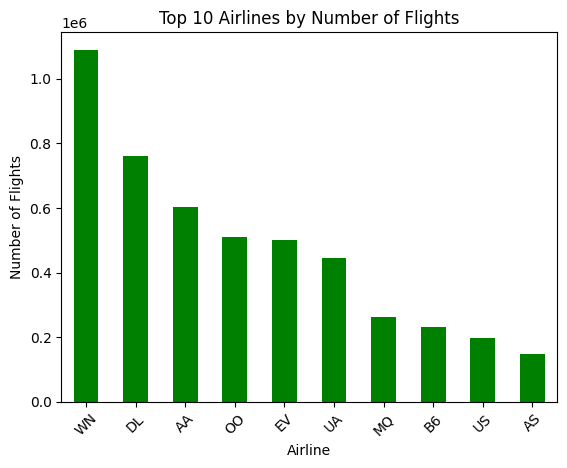

In [ ]:
# Count number of flights per airline
top_airlines = df['AIRLINE'].value_counts().head(10)

# Plot bar chart
plt.figure()
top_airlines.plot(kind='bar', color = 'green')
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

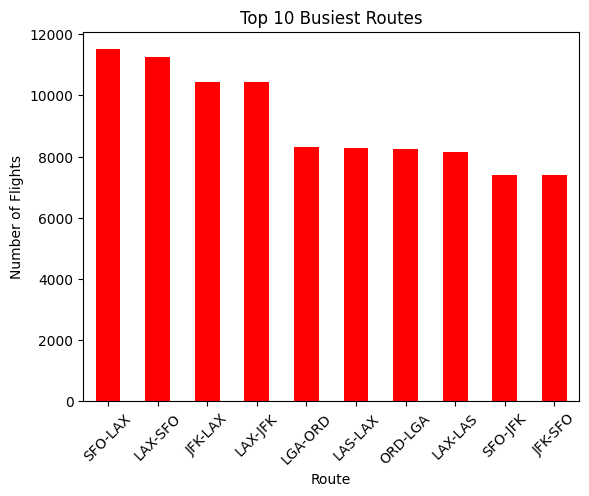

In [ ]:
# Top 10 busiest routes
top_routes = df['ROUTE'].value_counts().head(10)

# Plot bar chart
plt.figure()
top_routes.plot(kind='bar', color = 'red')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

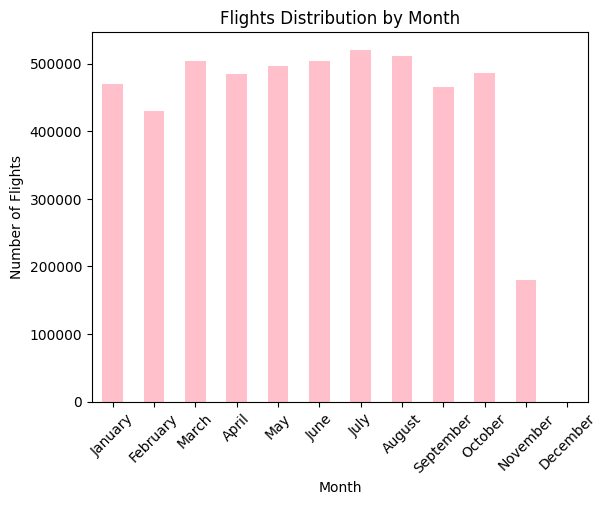

In [ ]:
# Count flights per month
monthly_flights = df['MONTH_NAME'].value_counts()

# Sort months in calendar order
monthly_flights = monthly_flights.reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Plot
plt.figure()
monthly_flights.plot(kind='bar', color = 'pink')
plt.title("Flights Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

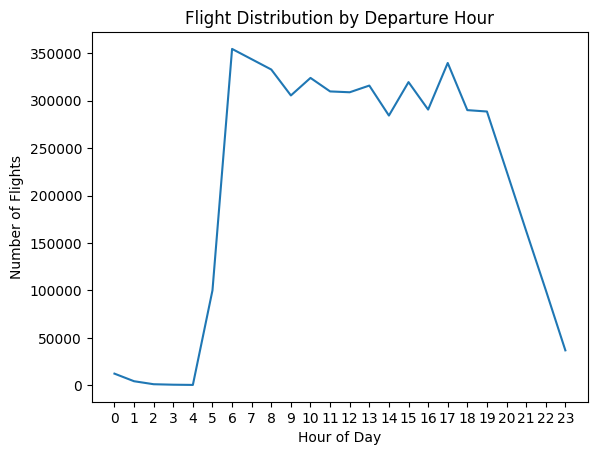

In [ ]:
# Count flights by departure hour
hourly_flights = df['DEPARTURE_HOUR'].value_counts().sort_index()

# Plot line chart
plt.figure()
plt.plot(hourly_flights.index, hourly_flights.values)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.xticks(range(0, 24))
plt.show()

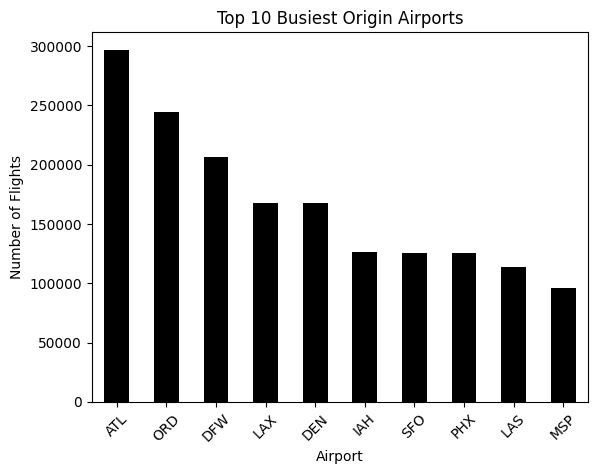

In [ ]:
# Top 10 busiest origin airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)

# Plot
plt.figure()
top_airports.plot(kind='bar', color = 'black')
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

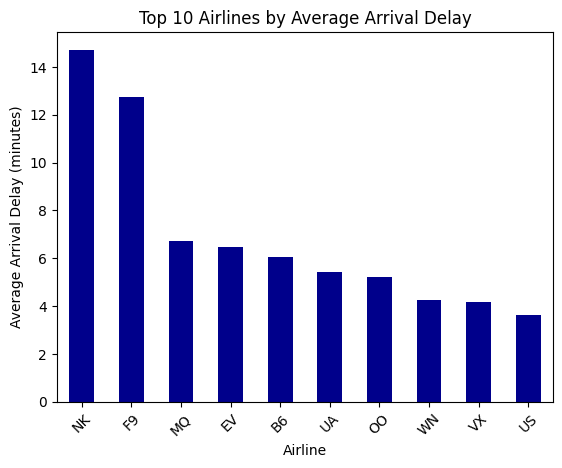

In [ ]:
# Calculate average arrival delay per airline
avg_delay_airline = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure()
avg_delay_airline.plot(kind='bar', color = 'darkblue')
plt.title("Top 10 Airlines by Average Arrival Delay")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

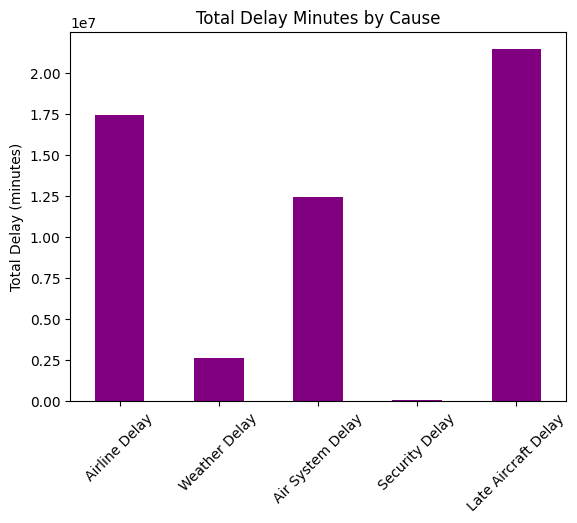

In [ ]:
# Sum total delay minutes by cause
delay_causes = {
    'Airline Delay': df['AIRLINE_DELAY'].sum(),
    'Weather Delay': df['WEATHER_DELAY'].sum(),
    'Air System Delay': df['AIR_SYSTEM_DELAY'].sum(),
    'Security Delay': df['SECURITY_DELAY'].sum(),
    'Late Aircraft Delay': df['LATE_AIRCRAFT_DELAY'].sum()
}

# Convert to Series
delay_series = pd.Series(delay_causes)

# Plot
plt.figure()
delay_series.plot(kind='bar', color = 'purple')
plt.title("Total Delay Minutes by Cause")
plt.ylabel("Total Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

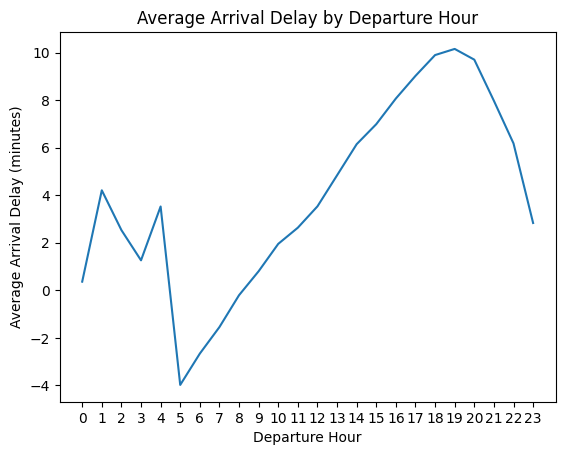

In [ ]:
# Average arrival delay by hour
hourly_delay = df.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean()

# Plot
plt.figure()
plt.plot(hourly_delay.index, hourly_delay.values)
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(0, 24))
plt.show()

Milestone - 3

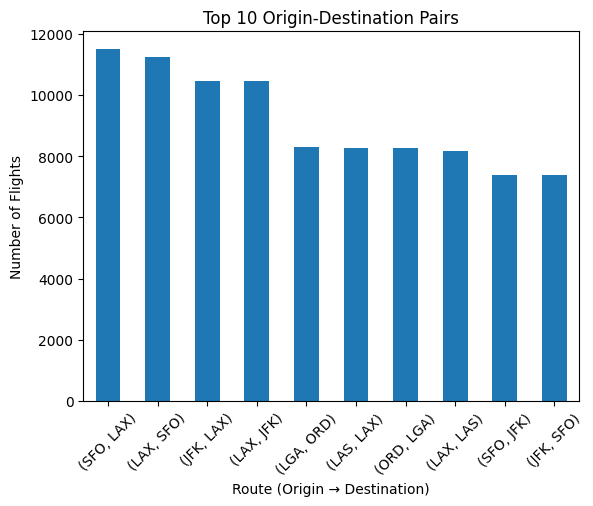

In [ ]:
# Top 10 origin-destination pairs
top_routes = df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).size().sort_values(ascending=False).head(10)

# Plot
plt.figure()
top_routes.plot(kind='bar')
plt.title("Top 10 Origin-Destination Pairs")
plt.xlabel("Route (Origin → Destination)")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

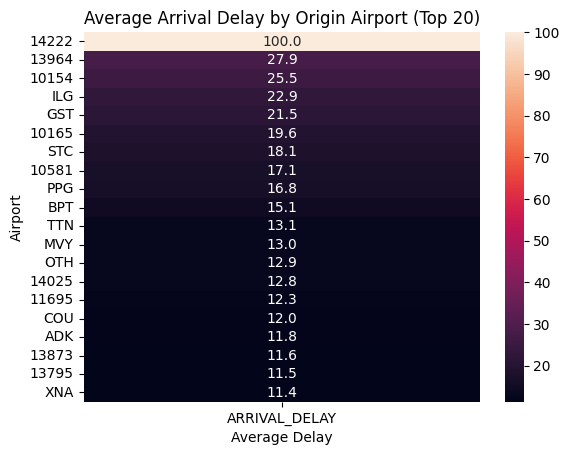

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average arrival delay per origin airport
airport_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(20)

# Convert to dataframe for heatmap
airport_delay_df = airport_delay.to_frame()

# Plot heatmap
plt.figure()
sns.heatmap(airport_delay_df, annot=True, fmt=".1f")
plt.title("Average Arrival Delay by Origin Airport (Top 20)")
plt.xlabel("Average Delay")
plt.ylabel("Airport")
plt.show()

In [ ]:
import folium

# Top 10 busiest airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)

# Example coordinates for major airports
airport_coords = {
    'ATL': (33.6407, -84.4277),
    'LAX': (33.9416, -118.4085),
    'ORD': (41.9742, -87.9073),
    'DFW': (32.8998, -97.0403),
    'DEN': (39.8561, -104.6737),
    'JFK': (40.6413, -73.7781),
    'SFO': (37.6213, -122.3790),
    'SEA': (47.4502, -122.3088),
    'LAS': (36.0840, -115.1537),
    'PHX': (33.4342, -112.0116)
}

# Create map
airport_map = folium.Map(location=[39.5, -98.35], zoom_start=4)

# Add airport markers
for airport, flights in top_airports.items():
    if airport in airport_coords:
        lat, lon = airport_coords[airport]
        folium.CircleMarker(
            location=[lat, lon],
            radius=10,
            popup=f"{airport}: {flights} flights",
            fill=True
        ).add_to(airport_map)

airport_map

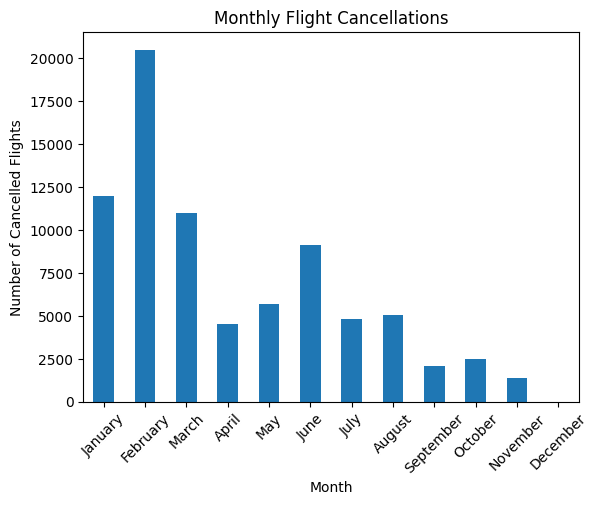

In [ ]:
# Filter cancelled flights
cancelled_flights = df[df['CANCELLED'] == 1]

# Count cancellations per month
monthly_cancellations = cancelled_flights['MONTH_NAME'].value_counts().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

# Plot
plt.figure()
monthly_cancellations.plot(kind='bar')
plt.title("Monthly Flight Cancellations")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Flights")
plt.xticks(rotation=45)
plt.show()

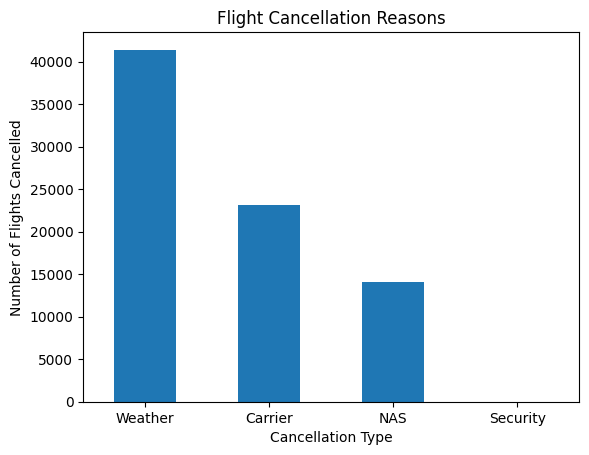

In [ ]:
# Count cancellation reasons
cancel_reason = df[df['CANCELLED'] == 1]['CANCELLATION_REASON'].value_counts()

# Replace codes with labels
cancel_reason.index = cancel_reason.index.map({
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'D': 'Security'
})

# Plot
plt.figure()
cancel_reason.plot(kind='bar')
plt.title("Flight Cancellation Reasons")
plt.xlabel("Cancellation Type")
plt.ylabel("Number of Flights Cancelled")
plt.xticks(rotation=0)
plt.show()

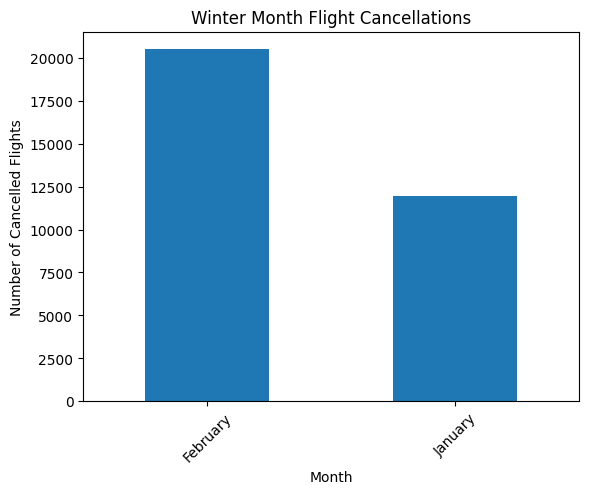

In [ ]:
# Filter cancelled flights
cancelled = df[df['CANCELLED'] == 1]

# Select winter months
winter_cancellations = cancelled[cancelled['MONTH_NAME'].isin(['December', 'January', 'February'])]

# Count cancellations by month
winter_counts = winter_cancellations['MONTH_NAME'].value_counts()

# Plot
plt.figure()
winter_counts.plot(kind='bar')
plt.title("Winter Month Flight Cancellations")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Flights")
plt.xticks(rotation=45)
plt.show()